# NLP Analysis — AI Coding Assistant Trust & Distrust
**COSC 3047 Assignment 2**

This notebook performs two NLP analyses on YouTube comments collected about AI coding assistants:

1. **Sentiment Analysis (VADER)** — classifies each comment as positive, negative, or neutral. VADER is a lexicon-based analyser designed for social media text. It handles informal language, capitalisation emphasis, and punctuation without requiring training data.

2. **Topic Modelling (LDA)** — discovers latent topics across the corpus and maps them to 5 research themes: productivity, reliability, security, cost, and code ownership. LDA is chosen over transformer-based approaches for interpretability and reproducibility — results are stable across runs with a fixed random seed (42), and term-topic distributions are directly inspectable.

**Input:** `data/processed/youtube/YTCommentsCleaned.csv`  
**Output:** `data/processed/nlp/`

## 1. Setup & Imports

In [1]:
import os
import json
import re
import logging
from pathlib import Path

import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel

# Silence gensim training logs
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)
logging.getLogger("gensim").setLevel(logging.WARNING)

# NLTK resources
for resource in ["stopwords", "punkt", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(resource, quiet=True)

print("Imports done.")

Imports done.


In [5]:
PROJECT_ROOT = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path.cwd().parents[1]
INPUT_PATH   = PROJECT_ROOT / "data/processed/youtube/YTCommentsCleaned.csv"
OUTPUT_DIR   = PROJECT_ROOT / "data/processed/nlp"
LDA_DIR      = OUTPUT_DIR / "lda_model"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df):,} comments from {df['videoId'].nunique()} videos")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loaded 23,871 comments from 165 videos
Columns: ['sourceQuery', 'searchRank', 'videoId', 'title', 'channelTitle', 'publishedAt', 'viewCount', 'likeCount', 'videoCommentCount', 'commentAuthor', 'commentText', 'commentType', 'parentAuthor', 'commentPublishedAt', 'commentLikeCount', 'commentTextClean', 'commentTextLower', 'commentLength']


,sourceQuery,searchRank,videoId,title,channelTitle,publishedAt,viewCount,likeCount,videoCommentCount,commentAuthor,commentText,commentType,parentAuthor,commentPublishedAt,commentLikeCount,commentTextClean,commentTextLower,commentLength
0,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@alsacs3635,Good overview. Thanks for sharing.,top_level,NaN,2026-05-15 02:18:09+00:00,0,Good overview. Thanks for sharing.,good overview. thanks for sharing.,34
1,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@thudtheace,Total trash!! Did you unleash copilot on GIT t...,top_level,NaN,2026-04-29 14:34:19+00:00,0,Total trash!! Did you unleash copilot on GIT t...,total trash!! did you unleash copilot on git t...,184
2,GitHub Copilot review developers,1,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,Visual Studio Code,2024-02-15 14:22:36+00:00,739081,9142,164,@moxopixel,Now it sucks,top_level,NaN,2026-04-24 16:04:13+00:00,0,Now it sucks,now it sucks,12


## 2. Configuration

### LDA Settings
`NUM_TOPICS = 6` matches our 5 research themes. `LDA_PASSES = 15` gives stable convergence on a corpus this size. `LDA_RANDOM_SEED = 42` ensures results are reproducible across runs.

### Theme Seeds
Each research theme is represented by seed words. After LDA training, each discovered topic is matched to the theme whose seeds overlap most with the topic's top terms. This mapping is saved to `topic_model_terms.json` and documented in the report.

### Stopwords
Domain-specific stopwords are added on top of NLTK's standard English list. These cover tool brand names (which appear in nearly every comment and carry no topical signal), YouTube creator names that polluted early topic runs, and filler phrases common in YouTube comments.

In [7]:
NUM_TOPICS      = 6
LDA_PASSES      = 15
LDA_RANDOM_SEED = 42

THEME_SEEDS = {
    "productivity":   ["faster", "speed", "time", "efficient", "workflow",
                       "automate", "quick", "save", "boilerplate", "autocomplete",
                       "suggest", "generate", "write", "complete"],
    "reliability":    ["bug", "error", "wrong", "incorrect", "broken",
                       "unreliable", "hallucinate", "mistake", "garbage",
                       "fix", "issue", "fail", "trash", "useless", "test"],
    "security":       ["security", "privacy", "data", "leak", "vulnerable",
                       "license", "safe", "risk", "expose", "telemetry"],
    "cost":           ["price", "expensive", "cheap", "cost", "subscription",
                       "free", "worth", "money", "pay", "pricing", "plan", "open"],
    "code_ownership": ["copyright", "ownership", "training", "stolen",
                       "plagiarism", "license", "legal", "intellectual",
                       "property", "scraping"],
    "job_displacement": ["job", "replace", "replacing", "replaced", "unemployed",
                     "fired", "layoff", "obsolete", "human", "engineer",
                     "developer", "programmer", "junior", "hire", "career"],
}

EXTRA_STOPWORDS = {
    "ai", "code", "coding", "use", "using", "used", "tool", "like", "just",
    "get", "got", "one", "would", "could", "really", "think", "know", "also",
    "github", "copilot", "cursor", "claude", "video", "comment", "people",
    "thing", "things", "make", "good", "great", "way", "work", "working",
    "much", "many", "still", "even", "well", "want", "need", "new", "go",
    # Creator/video noise
    "ali", "antigravity", "composer", "lex", "fridman", "bernie", "sanders",
    "cowork", "tutorial", "microsoft", "vscode", "codex", "gemini", "gpt",
    # Filler
    "thank", "thanks", "please", "nice", "awesome", "amazing", "love",
    "best", "better", "see", "say", "going", "something", "actually",
    "lol", "guy", "lot", "take", "first", "right", "already", "seems",
    "though", "basically", "completely"
}

stop_words = set(stopwords.words("english")) | EXTRA_STOPWORDS
print(f"Total stopwords: {len(stop_words)}")

Total stopwords: 278


## 3. Text Preprocessing

Comments are preprocessed before LDA by:
1. Lowercasing
2. Removing URLs, @mentions, #hashtags
3. Removing non-alphabetic characters
4. Tokenising
5. Removing stopwords and tokens shorter than 3 characters
6. Lemmatising

Note: VADER sentiment runs on **raw** text before preprocessing — preserving capitalisation and punctuation which VADER uses as sentiment signals.

In [8]:
def preprocess_text(text: str, stop_words: set, lemmatizer: WordNetLemmatizer) -> list:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[@#]\w+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) >= 3
    ]
    return tokens

print("preprocess_text defined.")

preprocess_text defined.


## 4. Sentiment Analysis (VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) assigns each comment a compound score from −1 (most negative) to +1 (most positive). Following VADER's recommended thresholds:
- **Positive**: compound ≥ 0.05
- **Negative**: compound ≤ −0.05
- **Neutral**: between −0.05 and 0.05

VADER is particularly suited to YouTube comments because it accounts for capitalisation (`GREAT` vs `great`), punctuation emphasis (`great!!!`), and common internet slang.

In [9]:
def run_sentiment_analysis(df: pd.DataFrame) -> pd.DataFrame:
    analyser = SentimentIntensityAnalyzer()
    results = []
    for text in df["commentText"].fillna(""):
        scores = analyser.polarity_scores(str(text))
        compound = scores["compound"]
        label = "neutral"
        if compound >= 0.05:
            label = "positive"
        elif compound <= -0.05:
            label = "negative"
        results.append({
            "sentiment_compound": compound,
            "sentiment_pos": scores["pos"],
            "sentiment_neg": scores["neg"],
            "sentiment_neu": scores["neu"],
            "sentiment_label": label
        })
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)

print("run_sentiment_analysis defined.")

run_sentiment_analysis defined.


In [10]:
sent_df = run_sentiment_analysis(df)

print(f"Sentiment distribution:")
print(sent_df["sentiment_label"].value_counts())
print(f"\nAverage compound score: {sent_df['sentiment_compound'].mean():.4f}")
sent_df[["commentTextClean", "sentiment_compound", "sentiment_label"]].head(5)

Sentiment distribution:
sentiment_label
positive    13430
neutral      6299
negative     4142
Name: count, dtype: int64

Average compound score: 0.2516


,commentTextClean,sentiment_compound,sentiment_label
0,Good overview. Thanks for sharing.,0.8225,positive
1,Total trash!! Did you unleash copilot on GIT t...,0.4276,positive
2,Now it sucks,-0.3612,negative
3,CNTL + ENTER sends stuff to the terminal for m...,0.0000,neutral
4,Wonderful Explanation,0.5719,positive


### Sentiment Visualisations

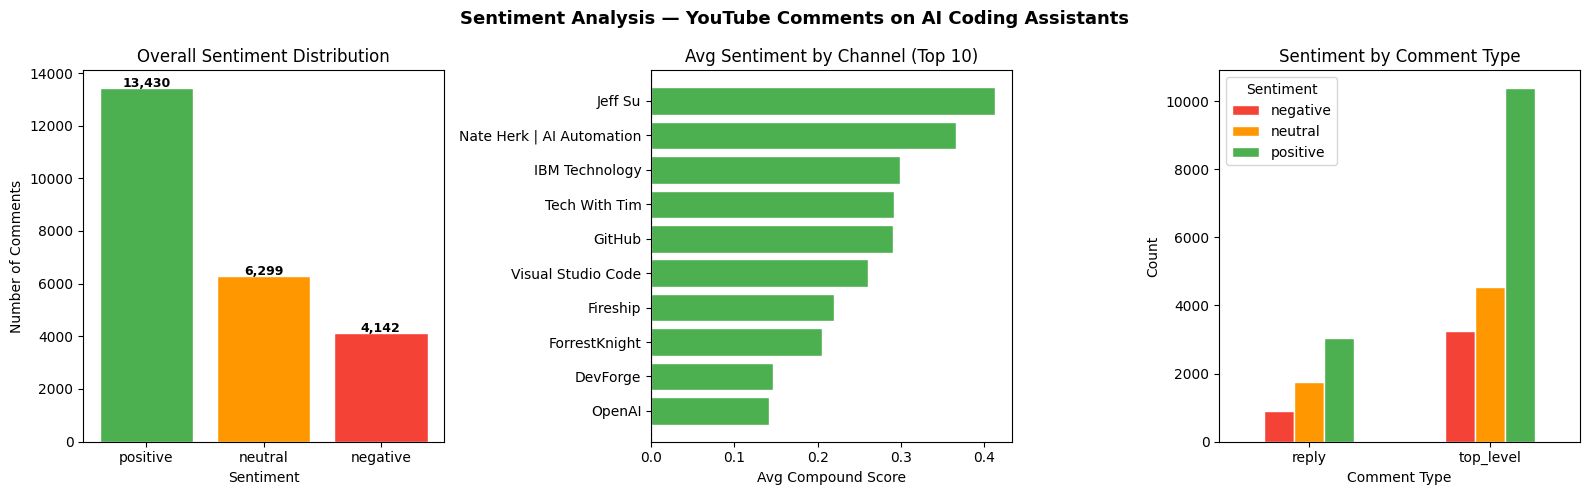

Saved sentiment_overview.png


In [11]:
COLORS = {"positive": "#4CAF50", "neutral": "#FF9800", "negative": "#F44336"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sentiment Analysis — YouTube Comments on AI Coding Assistants", fontsize=13, fontweight="bold")

# Plot 1 — Overall distribution
counts = sent_df["sentiment_label"].value_counts()
axes[0].bar(counts.index, counts.values, color=[COLORS[s] for s in counts.index], edgecolor="white")
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Comments")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold", fontsize=9)

# Plot 2 — Avg compound sentiment by top 10 channels
top_channels = sent_df["channelTitle"].value_counts().head(10).index
avg_sent = sent_df[sent_df["channelTitle"].isin(top_channels)].groupby("channelTitle")["sentiment_compound"].mean().sort_values()
bar_colors = ["#F44336" if v < 0 else "#4CAF50" for v in avg_sent.values]
axes[1].barh(avg_sent.index, avg_sent.values, color=bar_colors, edgecolor="white")
axes[1].axvline(x=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Avg Sentiment by Channel (Top 10)")
axes[1].set_xlabel("Avg Compound Score")

# Plot 3 — Sentiment by comment type
type_sent = sent_df.groupby(["commentType", "sentiment_label"]).size().unstack(fill_value=0)
type_sent.plot(kind="bar", ax=axes[2], color=[COLORS[c] for c in type_sent.columns], edgecolor="white")
axes[2].set_title("Sentiment by Comment Type")
axes[2].set_xlabel("Comment Type")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Sentiment")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved sentiment_overview.png")

## 5. Topic Modelling (LDA)

LDA models each comment as a mixture of latent topics, and each topic as a probability distribution over words. With `NUM_TOPICS=6` we expect to recover topics corresponding to our 5 research themes.

**Key decisions:**
- `no_below=5` — terms in fewer than 5 documents discarded as noise
- `no_above=0.7` — terms in more than 70% of documents discarded as uninformative
- `passes=15` — multiple passes improve topic stability
- `random_state=42` — fixed seed ensures reproducibility
- Saved model is loaded if available — delete `data/processed/nlp/lda_model/` to force retrain

In [12]:
def run_topic_modelling(sent_df: pd.DataFrame, stop_words: set):
    lemmatizer = WordNetLemmatizer()
    log.info("Preprocessing text for LDA...")
    texts = [
        preprocess_text(str(text), stop_words, lemmatizer)
        for text in sent_df["commentTextClean"].fillna("")
    ]
    texts = [t for t in texts if len(t) > 0]
    log.info(f"  {len(texts):,} non-empty documents after preprocessing")

    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=5, no_above=0.7)
    log.info(f"  Vocabulary size after filtering: {len(dictionary):,} terms")

    corpus = [dictionary.doc2bow(text) for text in texts]

    log.info(f"Training LDA ({NUM_TOPICS} topics, {LDA_PASSES} passes)...")
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        passes=LDA_PASSES,
        random_state=LDA_RANDOM_SEED,
        alpha="auto",
        eta="auto"
    )
    log.info("LDA training complete.")

    LDA_DIR.mkdir(parents=True, exist_ok=True)
    lda_model.save(str(LDA_DIR / "lda.model"))
    dictionary.save(str(LDA_DIR / "dictionary.gensim"))
    log.info(f"Model saved to {LDA_DIR}")

    return lda_model, dictionary


def map_topics_to_themes(lda_model: LdaModel, num_words: int = 15):
    topic_map = {}
    topic_terms = {}
    for topic_id in range(NUM_TOPICS):
        terms = [word for word, _ in lda_model.show_topic(topic_id, topn=num_words)]
        topic_terms[topic_id] = terms
        scores = {theme: sum(1 for t in terms if t in seeds) for theme, seeds in THEME_SEEDS.items()}
        best_theme = max(scores, key=scores.get)
        topic_map[topic_id] = best_theme if scores[best_theme] > 0 else "other"
        log.info(f"  Topic {topic_id} → '{topic_map[topic_id]}' | top terms: {', '.join(terms[:8])}")
    return topic_map, topic_terms


def assign_topics_to_comments(sent_df: pd.DataFrame, lda_model: LdaModel,
                               dictionary: corpora.Dictionary, topic_map: dict, stop_words: set) -> pd.DataFrame:
    lemmatizer = WordNetLemmatizer()
    topic_ids, topic_labels, topic_scores = [], [], []
    log.info("Assigning topics to comments...")
    for text in sent_df["commentTextClean"].fillna(""):
        tokens = preprocess_text(str(text), stop_words, lemmatizer)
        bow = dictionary.doc2bow(tokens)
        if not bow:
            topic_ids.append(None)
            topic_labels.append("unknown")
            topic_scores.append(0.0)
            continue
        topic_dist = lda_model.get_document_topics(bow)
        if not topic_dist:
            topic_ids.append(None)
            topic_labels.append("unknown")
            topic_scores.append(0.0)
            continue
        dominant = max(topic_dist, key=lambda x: x[1])
        topic_ids.append(int(dominant[0]))
        topic_labels.append(topic_map.get(dominant[0], "other"))
        topic_scores.append(round(float(dominant[1]), 4))
    log.info("Topic assignment complete.")
    result = sent_df.copy()
    result["dominant_topic_id"] = topic_ids
    result["topic_label"] = topic_labels
    result["topic_score"] = topic_scores
    return result

print("LDA functions defined.")

LDA functions defined.


### Train or Load LDA Model

In [13]:
if (LDA_DIR / "lda.model").exists() and (LDA_DIR / "dictionary.gensim").exists():
    log.info("Found existing LDA model — loading instead of retraining.")
    log.info("Delete data/processed/nlp/lda_model/ to force retrain.")
    lda_model = LdaModel.load(str(LDA_DIR / "lda.model"))
    dictionary = corpora.Dictionary.load(str(LDA_DIR / "dictionary.gensim"))
else:
    log.info("No saved model found — training from scratch.")
    lda_model, dictionary = run_topic_modelling(sent_df, stop_words)

# Map topics to themes
log.info("Mapping topics to research themes...")
topic_map, topic_terms = map_topics_to_themes(lda_model)

# Save topic terms for report
topic_terms_output = {
    str(tid): {"theme": topic_map[tid], "top_terms": terms}
    for tid, terms in topic_terms.items()
}
with open(OUTPUT_DIR / "topic_model_terms.json", "w") as f:
    json.dump(topic_terms_output, f, indent=2)
print("Saved topic_model_terms.json")

10:22:10 [INFO] No saved model found — training from scratch.
10:22:10 [INFO] Preprocessing text for LDA...
10:22:12 [INFO]   22,715 non-empty documents after preprocessing
10:22:13 [INFO]   Vocabulary size after filtering: 4,796 terms
10:22:13 [INFO] Training LDA (5 topics, 15 passes)...
10:22:28 [INFO] LDA training complete.
10:22:28 [INFO] Model saved to /Users/gayathwethmin/Downloads/social_media_2/data/processed/nlp/lda_model
10:22:28 [INFO] Mapping topics to research themes...
10:22:28 [INFO]   Topic 0 → 'other' | top terms: software, engineer, developer, company, job, human, problem, never
10:22:28 [INFO]   Topic 1 → 'productivity' | top terms: time, year, vibe, replace, programmer, learn, understand, day
10:22:28 [INFO]   Topic 2 → 'reliability' | top terms: agent, model, project, llm, app, prompt, build, language
10:22:28 [INFO]   Topic 3 → 'cost' | top terms: run, window, money, cost, pay, plan, token, api
10:22:28 [INFO]   Topic 4 → 'cost' | top terms: yes, bro, free, super,

Saved topic_model_terms.json


### Assign Topics to Comments

In [14]:
topic_df = assign_topics_to_comments(sent_df, lda_model, dictionary, topic_map, stop_words)

print("Topic distribution:")
print(topic_df["topic_label"].value_counts())

# Save enriched comments
topic_df.to_csv(OUTPUT_DIR / "comments_with_topics.csv", index=False)
print(f"\nSaved comments_with_topics.csv ({len(topic_df):,} rows)")

10:22:28 [INFO] Assigning topics to comments...
10:22:30 [INFO] Topic assignment complete.


Topic distribution:
topic_label
productivity    16634
reliability      3368
other            2113
unknown          1583
cost              173
Name: count, dtype: int64

Saved comments_with_topics.csv (23,871 rows)


### Topic Visualisations

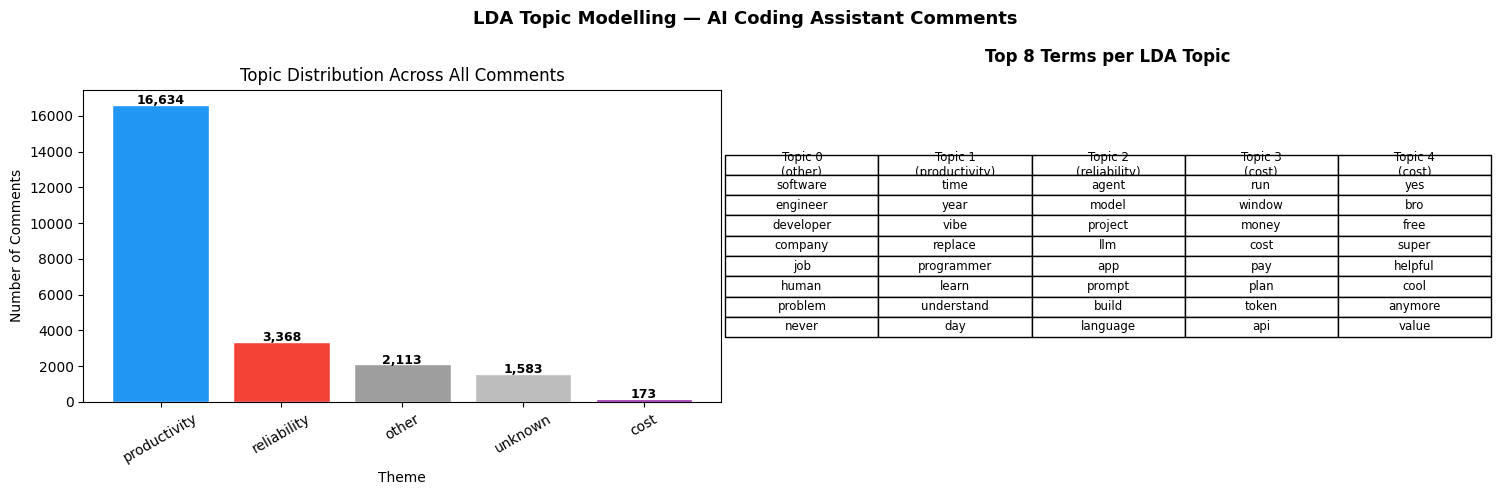

Saved topic_overview.png


In [15]:
TOPIC_COLORS = {
    "productivity": "#2196F3", "reliability": "#F44336",
    "security": "#FF9800", "cost": "#9C27B0",
    "code_ownership": "#009688", "other": "#9E9E9E", "unknown": "#BDBDBD"
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("LDA Topic Modelling — AI Coding Assistant Comments", fontsize=13, fontweight="bold")

# Plot 1 — Topic distribution
topic_counts = topic_df["topic_label"].value_counts()
bar_colors = [TOPIC_COLORS.get(t, "#9E9E9E") for t in topic_counts.index]
axes[0].bar(topic_counts.index, topic_counts.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Topic Distribution Across All Comments")
axes[0].set_xlabel("Theme")
axes[0].set_ylabel("Number of Comments")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(topic_counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Plot 2 — Top 8 terms per topic as a table
terms_data = {f"Topic {tid}\n({topic_map[tid]})": topic_terms[tid][:8] for tid in range(NUM_TOPICS)}
terms_df = pd.DataFrame(terms_data)
axes[1].axis("off")
table = axes[1].table(cellText=terms_df.values, colLabels=terms_df.columns,
                      cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 1.5)
axes[1].set_title("Top 8 Terms per LDA Topic", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topic_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved topic_overview.png")

## 6. Cross-Analysis — Sentiment × Topic

This is the key analytical step for the research question. By combining sentiment scores with topic labels we can identify:
- Which concern themes drive the most negative sentiment (distrust signals)
- Which themes are associated with positive sentiment (trust signals)
- How sentiment varies across topics — informing the network analysis stage

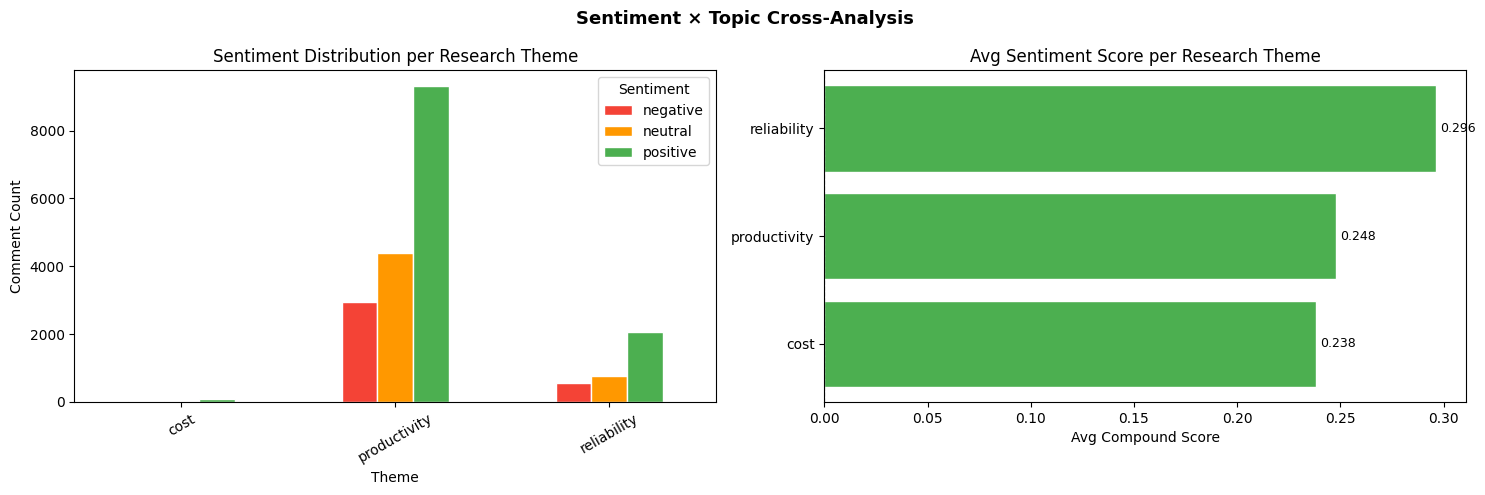

Saved sentiment_by_topic.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Sentiment × Topic Cross-Analysis", fontsize=13, fontweight="bold")

# Plot 1 — Sentiment breakdown per topic (stacked bar)
topic_sent = topic_df[topic_df["topic_label"].isin(THEME_SEEDS.keys())].groupby(
    ["topic_label", "sentiment_label"]
).size().unstack(fill_value=0)
topic_sent.plot(kind="bar", ax=axes[0],
                color=[COLORS.get(c, "#9E9E9E") for c in topic_sent.columns],
                edgecolor="white")
axes[0].set_title("Sentiment Distribution per Research Theme")
axes[0].set_xlabel("Theme")
axes[0].set_ylabel("Comment Count")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Sentiment")

# Plot 2 — Average compound sentiment per topic
avg_by_topic = topic_df[topic_df["topic_label"].isin(THEME_SEEDS.keys())].groupby(
    "topic_label"
)["sentiment_compound"].mean().sort_values()
bar_colors = ["#F44336" if v < 0 else "#4CAF50" for v in avg_by_topic.values]
axes[1].barh(avg_by_topic.index, avg_by_topic.values, color=bar_colors, edgecolor="white")
axes[1].axvline(x=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Avg Sentiment Score per Research Theme")
axes[1].set_xlabel("Avg Compound Score")
for i, v in enumerate(avg_by_topic.values):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved sentiment_by_topic.png")

## 7. Summary Statistics

In [17]:
summary = {
    "total_comments": len(topic_df),
    "overall_sentiment": topic_df["sentiment_label"].value_counts().to_dict(),
    "overall_topics": topic_df["topic_label"].value_counts().to_dict(),
    "avg_sentiment_by_channel": (
        topic_df.groupby("channelTitle")["sentiment_compound"].mean().round(4).to_dict()
    ),
    "sentiment_by_topic": (
        topic_df.groupby(["topic_label", "sentiment_label"])
        .size().unstack(fill_value=0).to_dict()
    ),
    "avg_sentiment_by_topic": (
        topic_df.groupby("topic_label")["sentiment_compound"].mean().round(4).to_dict()
    ),
    "sentiment_by_comment_type": (
        topic_df.groupby(["commentType", "sentiment_label"])
        .size().unstack(fill_value=0).to_dict()
    )
}

with open(OUTPUT_DIR / "summary_stats.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("NLP Pipeline Complete")
print(f"  Total comments analysed: {summary['total_comments']:,}")
print(f"  Sentiment:  {summary['overall_sentiment']}")
print(f"  Topics:     {summary['overall_topics']}")
print(f"  Avg sentiment by topic:")
for topic, score in summary["avg_sentiment_by_topic"].items():
    label = "positive" if score > 0.05 else "negative" if score < -0.05 else "neutral"
    print(f"    {topic:15s}: {score:+.4f} ({label})")
print("=" * 50)

NLP Pipeline Complete
  Total comments analysed: 23,871
  Sentiment:  {'positive': 13430, 'neutral': 6299, 'negative': 4142}
  Topics:     {'productivity': 16634, 'reliability': 3368, 'other': 2113, 'unknown': 1583, 'cost': 173}
  Avg sentiment by topic:
    cost           : +0.2384 (positive)
    other          : +0.2047 (positive)
    productivity   : +0.2480 (positive)
    reliability    : +0.2961 (positive)
    unknown        : +0.2590 (positive)


## 8. Outputs

All outputs saved to `data/processed/nlp/`:

| File | Description |
|---|---|
| `comments_with_topics.csv` | Every comment with VADER scores + topic label — input for network analysis |
| `topic_model_terms.json` | Top terms per LDA topic — used to justify theme mapping in report |
| `summary_stats.json` | Aggregate breakdowns by topic, sentiment, channel, comment type |
| `sentiment_overview.png` | Sentiment distribution charts |
| `topic_overview.png` | Topic distribution + top terms table |
| `sentiment_by_topic.png` | Cross-analysis of sentiment per research theme |
| `lda_model/` | Saved LDA model — load instead of retraining on subsequent runs |